BANK ATM SYSTEM SIMULATION
----------------------------------------
Number of ATM Machines = 3
Simulation Time = 500

Total Customers Served = 262
Maximum Queue Length = 12


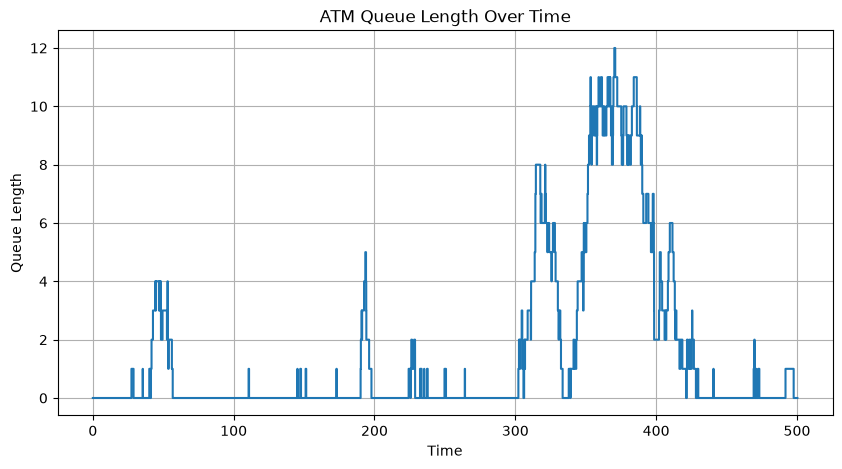

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

SIM_TIME = 500

NUM_ATMS = 3

MEAN_INTERARRIVAL = 2
MEAN_SERVICE = 4

# ---------------------------------
# Initial State
# ---------------------------------

clock = 0.0

queue = []

atm_departure_times = [float('inf')] * NUM_ATMS

next_arrival = np.random.exponential(MEAN_INTERARRIVAL)

max_queue_length = 0
served_customers = 0

time_points = [0]
queue_lengths = [0]

# ---------------------------------
# Simulation
# ---------------------------------

while clock < SIM_TIME:

    next_departure = min(atm_departure_times)

    next_event_time = min(next_arrival, next_departure)

    clock = next_event_time

    # -------- Arrival Event --------

    if next_arrival <= next_departure:

        free_atm = -1

        for i in range(NUM_ATMS):
            if atm_departure_times[i] == float('inf'):
                free_atm = i
                break

        if free_atm != -1:

            service_time = np.random.exponential(MEAN_SERVICE)

            atm_departure_times[free_atm] = (
                clock + service_time
            )

        else:

            queue.append(clock)

            if len(queue) > max_queue_length:
                max_queue_length = len(queue)

        next_arrival = (
            clock
            + np.random.exponential(MEAN_INTERARRIVAL)
        )

    # -------- Departure Event --------

    else:

        atm_index = atm_departure_times.index(
            next_departure
        )

        served_customers += 1

        if queue:

            queue.pop(0)

            service_time = np.random.exponential(
                MEAN_SERVICE
            )

            atm_departure_times[atm_index] = (
                clock + service_time
            )

        else:

            atm_departure_times[atm_index] = float('inf')

    time_points.append(clock)
    queue_lengths.append(len(queue))

# ---------------------------------
# Results
# ---------------------------------

print("BANK ATM SYSTEM SIMULATION")
print("-" * 40)

print("Number of ATM Machines =", NUM_ATMS)
print("Simulation Time =", SIM_TIME)

print("\nTotal Customers Served =",
      served_customers)

print("Maximum Queue Length =",
      max_queue_length)

# ---------------------------------
# Queue Length Graph
# ---------------------------------

plt.figure(figsize=(10,5))

plt.step(
    time_points,
    queue_lengths,
    where="post"
)

plt.xlabel("Time")
plt.ylabel("Queue Length")
plt.title("ATM Queue Length Over Time")
plt.grid(True)

plt.show()